## Math 586 - Research Project
# The Hypsometric Equation and SVD Analysis
Data from: https://products.climate.ncsu.edu/cardinal/scout/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 24.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from cartopy import crs, mpl
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import io

# import data from each mountain
ind = np.arange(2,14,3) # months: June 2025, September 2025, December 2025, March 2026

# Sassafras Mountain - elevation: 3525 ft
SASS = pd.read_csv('/content/drive/MyDrive/Math586Data/SASS_recent_data.csv',skiprows=4)
tSASS = SASS.iloc[ind,1].to_numpy()
pSASS = SASS.iloc[ind,2].to_numpy()

# Bearwallow Mountain - elevation: 4219 ft
BEAR = pd.read_csv('/content/drive/MyDrive/Math586Data/BEAR_recent_data.csv',skiprows=4)
tBEAR = BEAR.iloc[ind,1].to_numpy()
pBEAR = BEAR.iloc[ind,2].to_numpy()

# Grandfather Mountain - elevation: 5280 ft
GRAN = pd.read_csv('/content/drive/MyDrive/Math586Data/GRANDFATHR_recent_data.csv',skiprows=4)
tGRAN = GRAN.iloc[ind,1].to_numpy()
pGRAN = GRAN.iloc[ind,2].to_numpy()

# Frying Pan Mountain - elevation: 5320 ft
FRYI = pd.read_csv('/content/drive/MyDrive/Math586Data/FRYI_recent_data.csv',skiprows=4)
tFRYI = FRYI.iloc[ind,1].to_numpy()
pFRYI = FRYI.iloc[ind,2].to_numpy()

# Wayah Bald Mountain - elevation: 5469 ft
WINE = pd.read_csv('/content/drive/MyDrive/Math586Data/WINE_recent_data.csv',skiprows=4)
tWINE = WINE.iloc[ind,1].to_numpy()
pWINE = WINE.iloc[ind,2].to_numpy()

T = np.vstack((tSASS, tBEAR, tGRAN, tFRYI, tWINE))
P = np.vstack((pSASS, pBEAR, pGRAN, pFRYI, pWINE))

T = T + 273.15       # convert degrees Celsius to Kelvin

# space-time data matrices
print(T)
print(P)

z_a = np.array([3525, 4219, 5280, 5320, 5469]) # actual elevations for comparison
z_a = z_a * 0.3048   # convert ft to m

[[341.85 336.05 314.75 324.85]
 [339.05 333.25 309.55 321.65]
 [334.35 328.55 304.45 316.65]
 [335.95 329.95 309.45 319.85]
 [335.05 329.75 308.15 318.85]]
[[898.8  898.08 894.9  897.76]
 [878.02 877.16 871.63 875.92]
 [844.81 843.89 835.7  841.16]
 [844.36 843.3  836.74 841.34]
 [840.19 838.92 833.   837.34]]


We combine all temperature data into one matrix T and all pressure data into another matrix P. Each row represents a mountain, and each column represents a month. Temperature is converted to Kelvin because the hypsometric equation requires absolute temperature. We store the true elevations of each mountain (in meters). These values will be used to compare with our estimates.

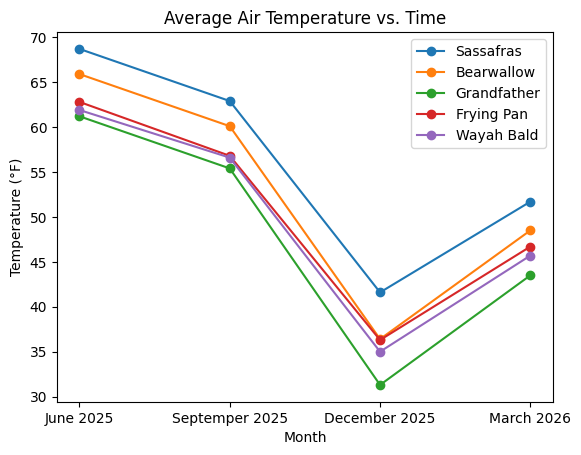

In [ ]:
# time series plots
months = ['June 2025', 'Septemper 2025', 'December 2025', 'March 2026']
mon = ['Jun','Sep','Dec','Mar']
mountains = ['Sassafras', 'Bearwallow', 'Grandfather', 'Frying Pan', 'Wayah Bald']

# Temperature vs. Time
plt.plot(months, tSASS, marker = 'o', label = mountains[0])
plt.plot(months, tBEAR, marker = 'o', label = mountains[1])
plt.plot(months, tGRAN, marker = 'o', label = mountains[2])
plt.plot(months, tFRYI, marker = 'o', label = mountains[3])
plt.plot(months, tWINE, marker = 'o', label = mountains[4])
plt.title("Average Air Temperature vs. Time")
plt.xlabel("Month")
plt.ylabel("Temperature (°F)")
plt.legend()
plt.show()

This plot shows how temperature changes over time for each mountain.

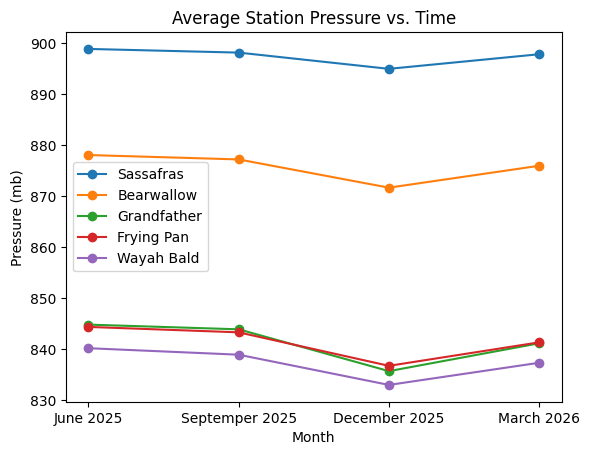

In [ ]:
# Pressure vs. Time
plt.plot(months, pSASS, marker = 'o', label = mountains[0])
plt.plot(months, pBEAR, marker = 'o', label = mountains[1])
plt.plot(months, pGRAN, marker = 'o', label = mountains[2])
plt.plot(months, pFRYI, marker = 'o', label = mountains[3])
plt.plot(months, pWINE, marker = 'o', label = mountains[4])
plt.title("Average Station Pressure vs. Time")
plt.xlabel("Month")
plt.ylabel("Pressure (mb)")
plt.legend()
plt.show()

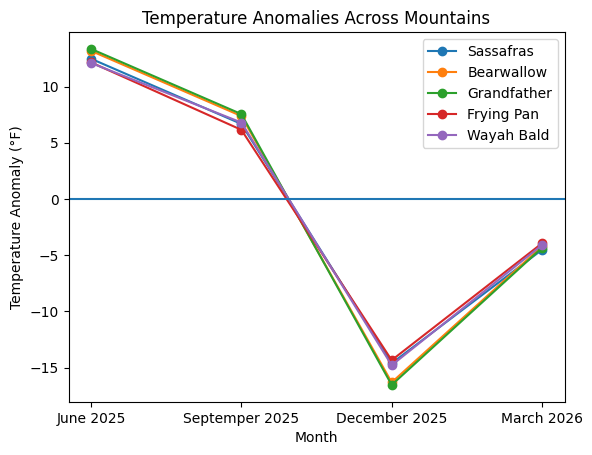

In [ ]:
#Temp Anomalies Across Mountains
temps = np.array([tSASS, tBEAR, tGRAN, tFRYI, tWINE])

# Compute mean for each mountain
mean_temp = np.mean(temps, axis=1, keepdims=True)

# Compute anomalies
anom = temps - mean_temp

# Plot
for i in range(5):
    plt.plot(months, anom[i], marker='o', label=mountains[i])

plt.axhline(0)  # zero line
plt.title("Temperature Anomalies Across Mountains")
plt.xlabel("Month")
plt.ylabel("Temperature Anomaly (°F)")
plt.legend()
plt.show()

This graph shows how atmospheric pressure changes over time.

The Hypsometric Equation:
$$ z_2 = z_1 + \frac{2 R T_1 T_2}{g(T_2 + T_1)} \ln\left(\frac{p_1}{p_2}\right) $$

In [ ]:
# hypsometric equation
R = 287.055    # gas constant (J/kg*K)
g = 9.81       # gravity (m/s^2)
Z_a = np.column_stack((z_a, z_a, z_a, z_a))
Z = Z_a.copy()

def height(z1, T1, T2, p1, p2):
    return z1 + (2*R*T1*T2)/(g*(T1+T2))*np.log(p1/p2)

# The mountains are in order from shortest to tallest.
# We use Sassafras as our base mountain and calculate the heights
# for each mountain based on the mountain before it.

for i in range(4):
    for j in range(4):
        Z[i+1,j] = height(Z[i,j], T[i,j], T[i+1,j], P[i,j], P[i+1,j])

print(Z/0.3048) # Calculated elevation in ft
RelErr = np.abs(Z_a - Z)/Z_a # relative error
print(RelErr)


[[3525.         3525.         3525.         3525.        ]
 [4289.50274031 4282.214776   4314.48673438 4289.25510876]
 [5535.77621531 5510.5005561  5555.06287197 5529.84407711]
 [5552.91922439 5532.60720932 5518.41634534 5523.30696383]
 [5712.38075219 5697.50691858 5651.21998765 5669.413584  ]]
[[0.         0.         0.         0.        ]
 [0.01671077 0.01498336 0.02263255 0.01665208]
 [0.04844247 0.04365541 0.05209524 0.04731895]
 [0.04378181 0.03996376 0.03729631 0.03821559]
 [0.04450187 0.04178221 0.0333187  0.03664538]]


We define the hypsometric equation as a function. It calculates the height difference between two locations using temperature and pressure.
We use Sassafras as the base elevation and compute the heights of the other mountains step by step. This gives us estimated elevations for each month. We calculate the relative error to measure how accurate our estimated elevations are compared to the true values.

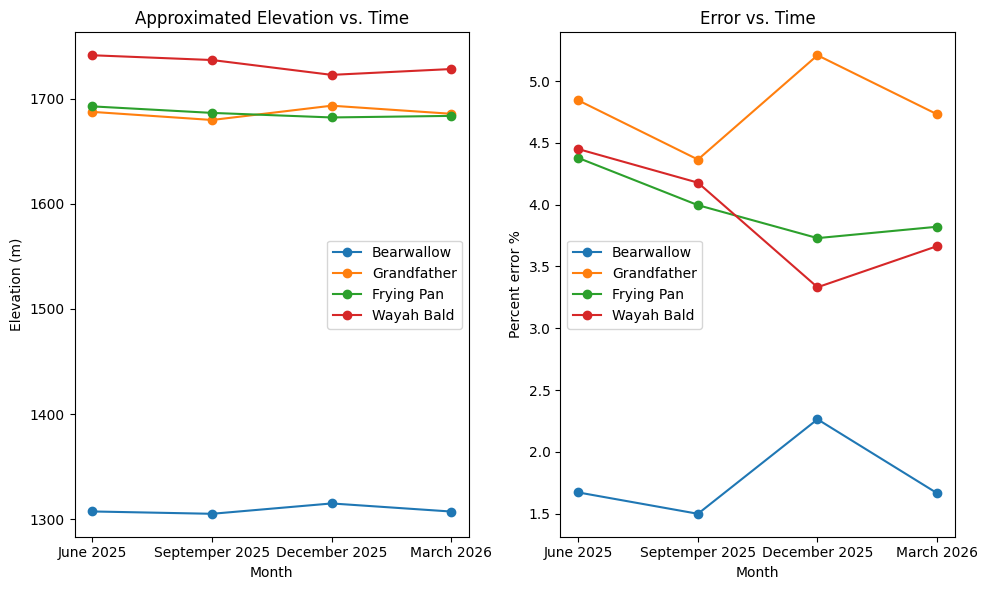

In [ ]:
# Calculated Elevation and error vs. Time
Elev = Z[1:,:]
PerErr = RelErr[1:,:]*100

plt.figure(figsize=(10, 6))
plt.subplot(1,2,1)
for i in range(4):
    plt.plot(months, Elev[i,:], marker = 'o', label = mountains[i+1])
plt.title("Approximated Elevation vs. Time")
plt.xlabel("Month")
plt.ylabel("Elevation (m)")
plt.legend()

plt.subplot(1,2,2)
for i in range(4):
    plt.plot(months, PerErr[i,:], marker = 'o', label = mountains[i+1])
plt.title("Error vs. Time")
plt.xlabel("Month")
plt.ylabel("Percent error %")
plt.legend()

plt.tight_layout()
plt.show()

We plot estimated elevation and percent error to evaluate how the model performs over time.

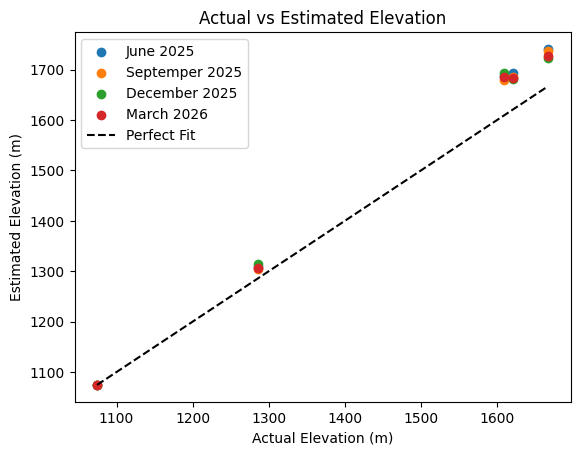

In [ ]:
#Actual vs Estimated Elevation
plt.figure()
for j in range(4):
    plt.scatter(z_a, Z[:,j], label=months[j])

plt.plot(z_a, z_a, 'k--', label="Perfect Fit")

plt.title("Actual vs Estimated Elevation")
plt.xlabel("Actual Elevation (m)")
plt.ylabel("Estimated Elevation (m)")
plt.legend()
plt.show()

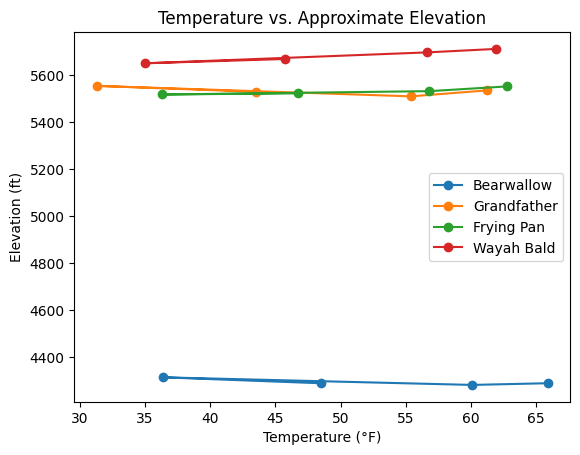

In [ ]:
# Temperature vs. Approximate Elevation
plt.figure()
plt.plot(tBEAR, Elev[0,:]/0.3048, marker = 'o', label = mountains[1])
plt.plot(tGRAN, Elev[1,:]/0.3048, marker = 'o', label = mountains[2])
plt.plot(tFRYI, Elev[2,:]/0.3048, marker = 'o', label = mountains[3])
plt.plot(tWINE, Elev[3,:]/0.3048, marker = 'o', label = mountains[4])
plt.title("Temperature vs. Approximate Elevation")
plt.xlabel("Temperature (°F)")
plt.ylabel("Elevation (ft)")
plt.legend()
plt.show()

Singular Values: [1.85195035e+01 8.87281495e+00 1.88509095e+00 3.46152531e-14]

EOF Modes (U):
[[-0.35155218 -0.37370313 -0.83492515 -0.19914073]
 [-0.38489285 -0.73481112  0.39734889  0.39245889]
 [ 0.37028432 -0.472999    0.23784906 -0.76327537]
 [ 0.76886806 -0.31091886 -0.29739145  0.47300074]]


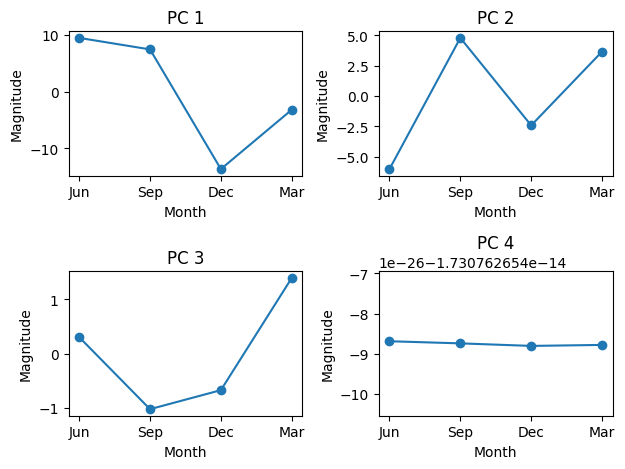

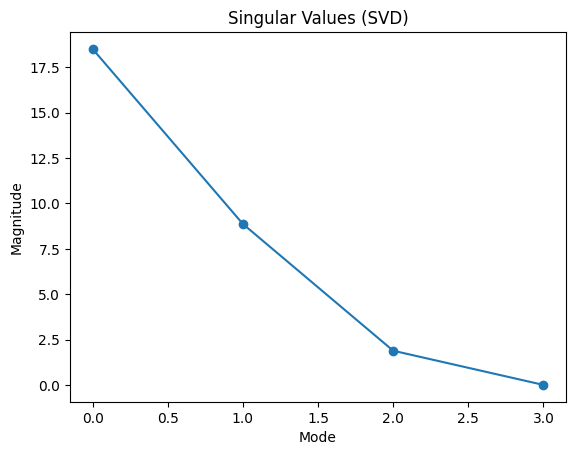

In [ ]:
# SVD analysis
Zanom = Elev - np.mean(Elev, axis=1, keepdims=True)
# SVD
U, S, VT = np.linalg.svd(Zanom, full_matrices=False)

print("Singular Values:", S)
print("\nEOF Modes (U):")
print(U)

for i in range(4):
  plt.subplot(2,2,i+1)
  plt.plot(mon, VT[i,:]*S[i], marker='o')
  plt.title(f"PC {i+1}")
  plt.xlabel("Month")
  plt.ylabel("Magnitude")

plt.tight_layout()
plt.show()

# Plot singular values
plt.figure()
plt.plot(S, marker='o')
plt.title("Singular Values (SVD)")
plt.xlabel("Mode")
plt.ylabel("Magnitude")
plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


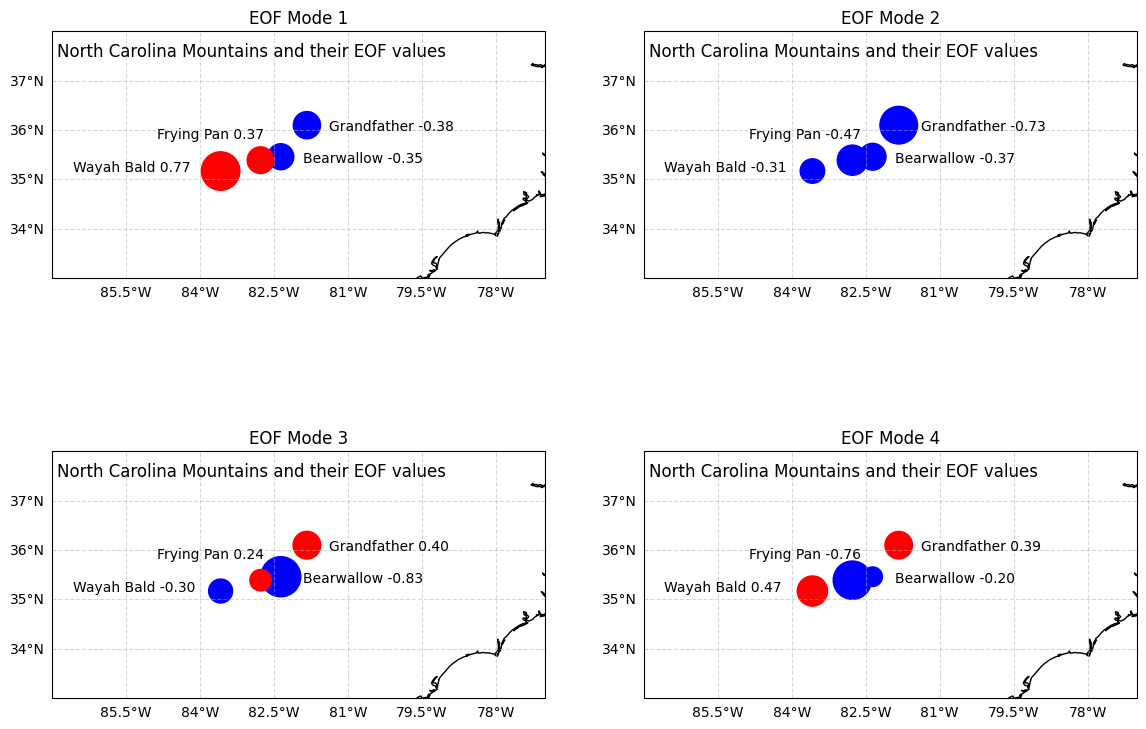

In [ ]:
# EOF plots
# Carolinas:
lon_min, lon_max = -87, -77
lat_min, lat_max = 33, 38
fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 10),
    subplot_kw={'projection': crs.PlateCarree()}
)
axes = axes.flatten()

# longitudes and latitudes of our mountains:
lons = np.array([-82.36, -81.83, -82.77, -83.58])
lats = np.array([35.46, 36.10, 35.39, 35.17])

for k in range(4):
    ax = axes[k]

    ax.set_extent([lon_min, lon_max, lat_min, lat_max])
    ax.coastlines()

    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # color by sign of EOF value
    colors = np.where(U[:, k] >= 0, 'r', 'b')
    sc = ax.scatter(
        lons, lats,
        c=colors,
        s=np.abs(U[:, k]) * 1000,
    )

    ax.set_title(f'EOF Mode {k+1}')
    ax.text(-86.9, 37.5, "North Carolina Mountains and their EOF values", fontsize=12)

    lon_adj = np.array([0.45, 0.45, -2.1, -3])
    lat_adj = np.array([-0.1, -0.1, 0.45, 0])
    for i in range(4):
        ax.text(lons[i]+lon_adj[i], lats[i]+lat_adj[i], f"{mountains[i+1]} {U[i,k]:.2f}", fontsize=10)

plt.show()